Model for shark growth


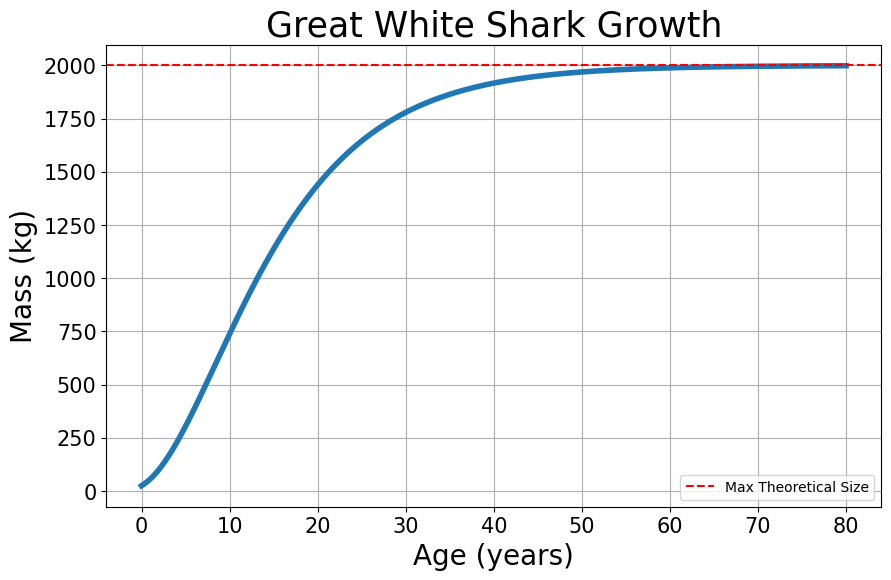

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Model for shark growth")

# --- PARAMETERS ---
b = 0.3                                 
M_max = 2000 

a = b * (M_max)**(1/3) # if we set dmdt = 0 we can rearrange the equation and solve for a 

# --- INITIALIZATION ---
Dt = 0.01                               # timestep (0.01 years)
t_end = 80                              # End of simulation (Lifespan)
n_steps = int(round(t_end/Dt))          # total timesteps

t_arr = np.zeros(n_steps + 1)           
M_arr = np.zeros(n_steps + 1)           

t_arr[0] = 0                            # Birth time
M_arr[0] = 25                           # Birth mass (kg)

# --- EULER'S METHOD ---
for i in range (1, n_steps + 1):
    M = M_arr[i-1]
    t = t_arr[i-1]
    
    # The differential equation:
    dMdt = a * M**(2/3) - b * M         
    
    M_arr[i] = M + Dt*dMdt              
    t_arr[i] = t + Dt                   

# --- PLOTTING ---
fig = plt.figure(figsize=(10,6))                   
plt.plot(t_arr, M_arr, linewidth = 4)   

plt.title('Great White Shark Growth', fontsize = 25)  
plt.xlabel('Age (years)', fontsize = 20)
plt.ylabel('Mass (kg)', fontsize = 20)

plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)    

plt.axhline(y=M_max, color='r', linestyle='--', label='Max Theoretical Size')
plt.legend()

plt.show()                              
fig.savefig('Simulation_Result.jpg', dpi=fig.dpi, bbox_inches = "tight")

dirrection field shark growth


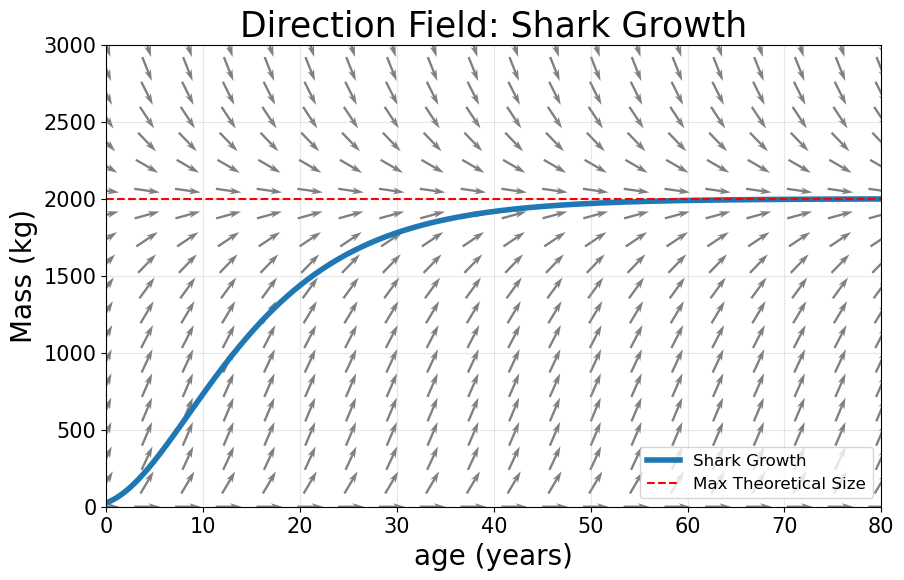

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

print("dirrection field shark growth")

b = 0.3
M_max = 2000 # realistic final weight for great white shark

a = b*M_max**(1/3) # we calculate a again

#plot ranges
t_end = 80 #( the lifespan of the shark)
M_plot_max = 3000 #we set the mass higher than the max mass so we can see the entire direction field

# here we generate the grid
n = 20 # i just experimented what value of n works best
x_,y_ = np.linspace(0,1,n),np.linspace(0,1,n) # we use a normalised grid 
x,y = np.meshgrid(x_,y_) 

M = y*M_plot_max # the mass is just the y coordinate but since we normalised we need to multiply by the max value
DMDT = a*M**(2/3) - b*M

# now we need to convert the derivative to the arrows of our direction field
visual_slope = DMDT * t_end/M_plot_max # we got this formula from DMDT(norm) = (DM/m_max)/(DT/t_max) = DM/DT * t_max/m_max
length_vectors = np.sqrt(1+visual_slope**2)
u,v = 1/length_vectors, visual_slope/length_vectors


#initialize for euler
Dt = 0.1
t_arr = np.arange(0, t_end + Dt, Dt) 
n_steps = len(t_arr)
M_arr = np.zeros(n_steps)
M_arr[0] = 25 # a realistic initial weight for a great white shark

for i in range (1, n_steps):
    M = M_arr[i-1]
    t = t_arr[i-1]
    
    # The differential equation:
    dMdt = a * M**(2/3) - b * M         
    
    M_arr[i] = M + Dt*dMdt              
    t_arr[i] = t + Dt                   

# --- PLOTTING ---
fig = plt.figure(figsize=(10, 6))

# 1. Plot Arrows
plt.quiver(x, y, u, v, color='gray', pivot='mid', scale=30, headaxislength=4, width=0.003)

# 2. Plot Solution Curve (Normalized)
plt.plot(t_arr/t_end, M_arr/M_plot_max, linewidth=4, label='Shark Growth')

# 3. Plot Asymptote
plt.axhline(M_max/M_plot_max, color='r', linestyle='--', label='Max Theoretical Size')


# 4. Fix Labels (Fake the axes to show real numbers)
plt.xticks(np.linspace(0, 1, 9), np.linspace(0, t_end, 9).astype(int), fontsize=15) # i found this is how to overwrite the x and y axises so we dont get the normalised values
plt.yticks(np.linspace(0, 1, 7), np.linspace(0, M_plot_max, 7).astype(int), fontsize=15)



plt.title('Direction Field: Shark Growth', fontsize=25)
plt.xlabel('age (years)', fontsize=20)
plt.ylabel('Mass (kg)', fontsize=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='lower right')

plt.show()

Phase Line Plot


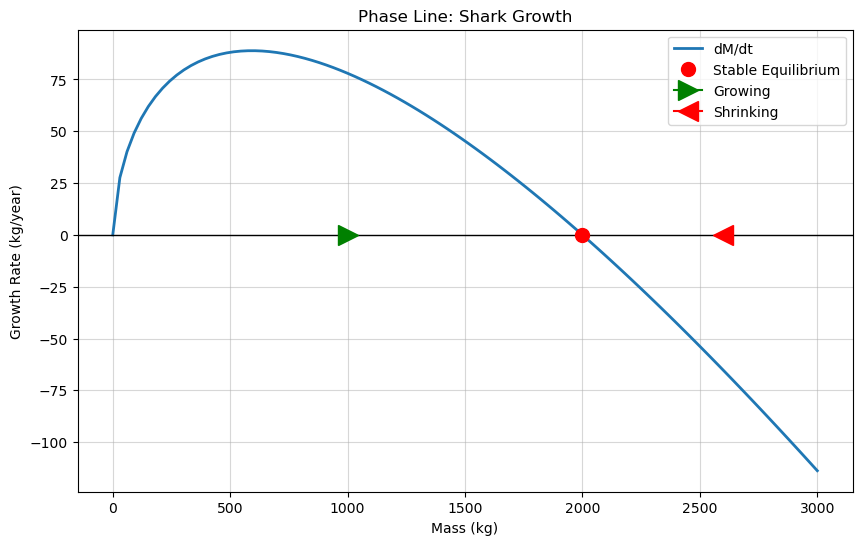

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

print("Phase Line Plot")

# Model parameters
b = 0.3
final_mass = 2000 
a = b * final_mass**(1/3) 

# Generate data
# We check weights from 0 up to 3000 to see both growth and decay
current_mass = np.linspace(0, 3000, 100)
growth_rate = a * current_mass**(2/3) - b * current_mass

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot the differential equation curve
plt.plot(current_mass, growth_rate, linewidth=2, label='dM/dt')
plt.axhline(0, color='black', linewidth=1)

# Mark the equilibrium point
plt.plot(final_mass, 0, 'ro', markersize=10, label='Stable Equilibrium')

# Add flow arrows to the axis
plt.plot(1000, 0, marker='>', color='green', markersize=15, label='Growing')
plt.plot(2600, 0, marker='<', color='red',   markersize=15, label='Shrinking')

plt.title('Phase Line: Shark Growth')
plt.xlabel('Mass (kg)')
plt.ylabel('Growth Rate (kg/year)')
plt.grid(True, alpha=0.5)
plt.legend()

plt.show()

Model for shark growth - Numerical Verification
Inputs: a=3.8, b=0.3
Mathematical Theory predicts equilibrium at: 2032.30 kg
Simulation finished at: 2030.74 kg


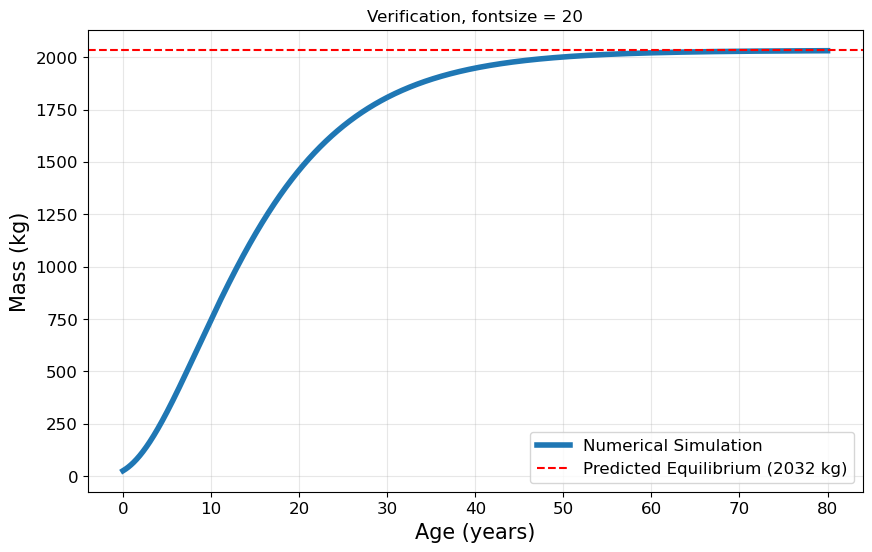

In [4]:
# Program      : Euler's method modified for shark growth (Blind Test)

import numpy as np
import matplotlib.pyplot as plt

print("Model for shark growth - Numerical Verification")

# --- 1. BLIND PARAMETERS ---
# We pick arbitrary coefficients for a and b 
# We do Not define M_max (this prevents circular reasoning
a = 3.8   # Anabolism coefficient (growth rate)
b = 0.3   # Catabolism coefficient (energy loss rate)

# --- 2. ANALYTICAL PREDICTION ---
# We calculate the theoretical limit using the formula: M = (a/b)^3
M_predicted = (a / b)**3 

print(f"Inputs: a={a}, b={b}")
print(f"Mathematical Theory predicts equilibrium at: {M_predicted:.2f} kg")

# --- 3. SIMULATION SETUP ---
Dt = 0.05                               # timestep (0.05 years)
t_end = 80                              # End of simulation (Lifespan)
n_steps = int(round(t_end/Dt))          # total timesteps

t_arr = np.zeros(n_steps + 1)           
M_arr = np.zeros(n_steps + 1)           

t_arr[0] = 0                            # Birth time
M_arr[0] = 25                           # Birth mass (kg)

# --- 4. EULER'S METHOD ---
for i in range (1, n_steps + 1):
    M = M_arr[i-1]
    t = t_arr[i-1]
    
    # The differential equation:
    dMdt = a * M**(2/3) - b * M         
    
    M_arr[i] = M + Dt*dMdt              
    t_arr[i] = t + Dt                   

print(f"Simulation finished at: {M_arr[-1]:.2f} kg")

# --- 5. PLOT THE RESULTS ---
fig = plt.figure(figsize=(10,6))                   

# Plot the simulation line
plt.plot(t_arr, M_arr, linewidth = 4, label='Numerical Simulation')   

# Plot the predicted math value to verify they match
plt.axhline(y=M_predicted, color='r', linestyle='--', label=f'Predicted Equilibrium ({int(M_predicted)} kg)')

plt.title('Verification, fontsize = 20')  
plt.xlabel('Age (years)', fontsize = 15)
plt.ylabel('Mass (kg)', fontsize = 15)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.grid(True, alpha=0.3)    
plt.legend(fontsize=12)

plt.show()                              
fig.savefig('Blind_Test_Result.jpg', dpi=fig.dpi, bbox_inches = "tight")

0.78
5.349015099450482


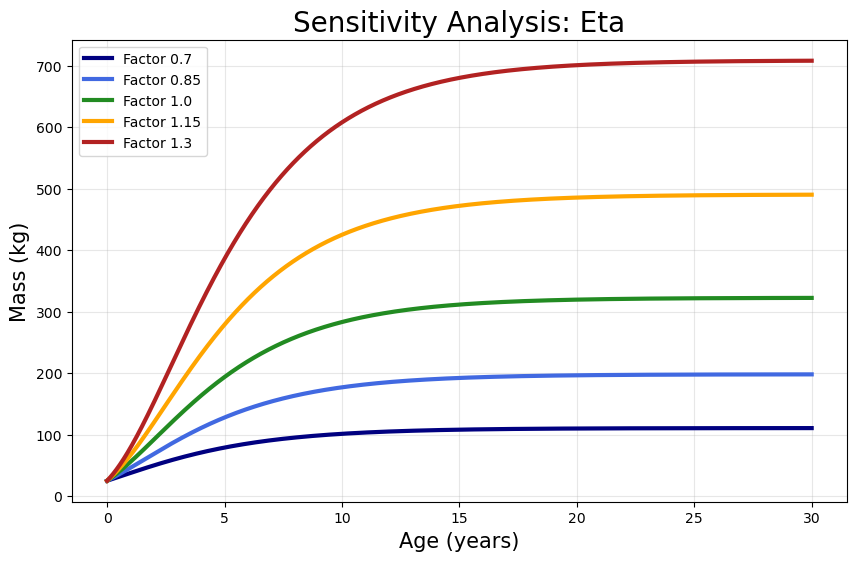

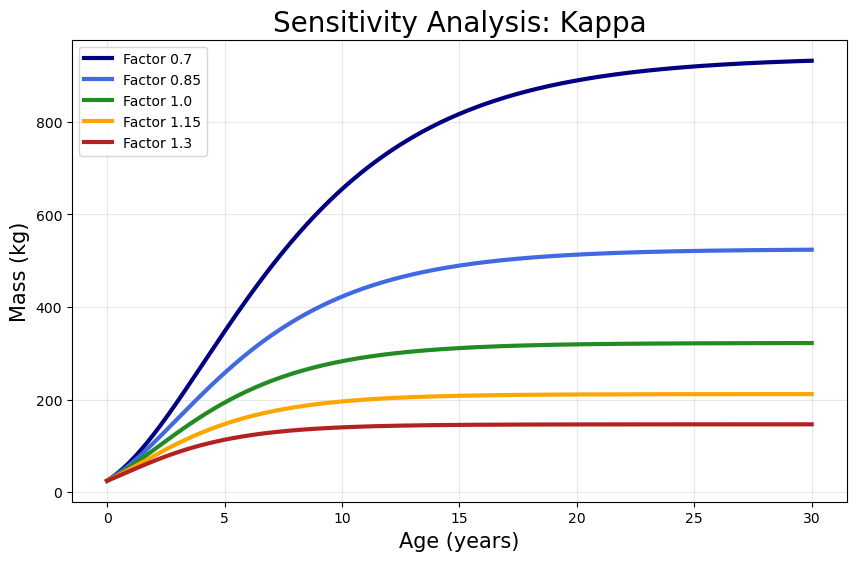

In [28]:
import numpy as np

# --- 1. Growth Parameters ---
# Pratt and Casey (1983)
# Table 2 / Results for Males
k_vb = 0.26        # Growth coefficient (year^-1)
L_inf = 302        # Asymptotic length (cm)

# --- 2. Length-Weight Conversion ---
# Source: Kohler et al. (1995) - "Length-weight relationships..."
# Table 2 (Shortfin mako): W = a * L^b
a = 5.243e-6          
b = 3.1407            

# Calculate Asymptotic Weight (W_inf)
w_inf = a * (L_inf ** b)



# kappa = 3 * k (standard derivation)
base_kappa = 3 * k_vb
print(base_kappa)


# eta = kappa * W_inf^(1/3)
base_eta = kappa * (w_inf**(1/3))
print(base_eta)



factors = [0.7, 0.85, 1.0, 1.15, 1.3]


# --- INITIALIZATION ---
Dt = 0.01                               # timestep (0.01 years)
t_end = 30                              # End of simulation (Lifespan)
n_steps = int(round(t_end/Dt))          # total timesteps

t_arr = np.zeros(n_steps + 1)           
M_arr = np.zeros(n_steps + 1)           

t_arr[0] = 0                            # Birth time
M_arr[0] = 25                           # Birth mass (kg)

colors = ['navy', 'royalblue', 'forestgreen', 'orange', 'firebrick'] #the colors for our plot

# ========================================== 
# PLOT 1: ETA SENSITIVITY
# ==========================================
fig = plt.figure(figsize=(10,6))  


for i, fact in enumerate(factors):
    kappa = base_kappa
    eta = base_eta * fact
    
    # reset starting mass 
    M_arr[0] = 25
    
    for j in range (1, n_steps + 1):
        M = M_arr[j-1]
        t = t_arr[j-1]
        
        dMdt = eta * M**(2/3) - kappa * M         
        
        M_arr[j] = M + Dt*dMdt              
        t_arr[j] = t + Dt                   

    # Use 'i' to grab the correct color
    plt.plot(t_arr, M_arr, linewidth=3, color=colors[i], label=f'Factor {fact}')   

plt.title('Sensitivity Analysis: Eta', fontsize=20)  
plt.xlabel('Age (years)', fontsize=15)
plt.ylabel('Mass (kg)', fontsize=15)
plt.grid(True, alpha=0.3)    
plt.legend()
plt.show()

# ==========================================
# PLOT 2: KAPPA SENSITIVITY
# ==========================================
fig = plt.figure(figsize=(10,6))  

# Using enumerate again
for i, fact in enumerate(factors):
    kappa = base_kappa * fact
    eta = base_eta 
    
    # Reset starting mass
    M_arr[0] = 25

    for j in range (1, n_steps + 1):
        M = M_arr[j-1]
        t = t_arr[j-1]
        
        dMdt = eta * M**(2/3) - kappa * M         
        
        M_arr[j] = M + Dt*dMdt              
        t_arr[j] = t + Dt                   

    
    plt.plot(t_arr, M_arr, linewidth=3, color=colors[i], label=f'Factor {fact}')   

plt.title('Sensitivity Analysis: Kappa', fontsize=20)  
plt.xlabel('Age (years)', fontsize=15)
plt.ylabel('Mass (kg)', fontsize=15)
plt.grid(True, alpha=0.3)    
plt.legend()
plt.show()



Model for shark growth


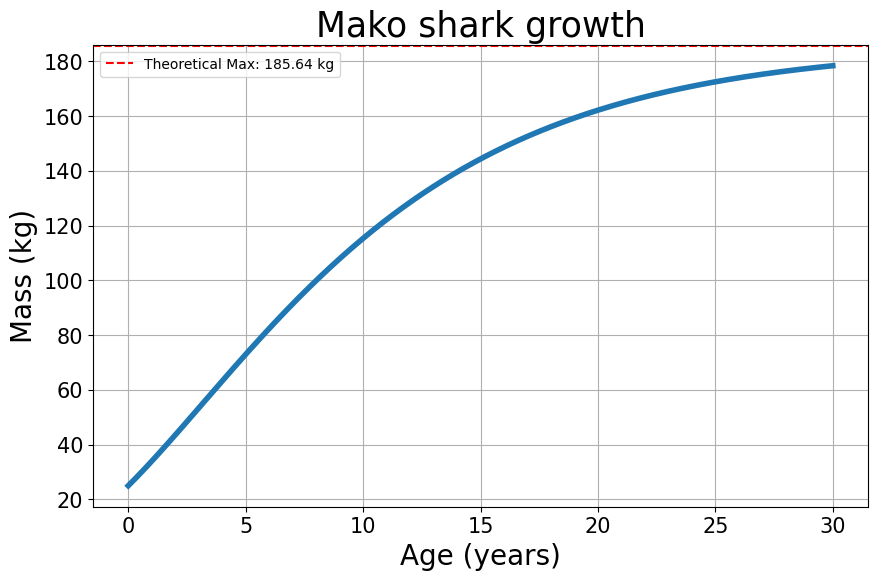

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("Model for shark growth")




import numpy as np

# --- 1. Growth Parameters ---
#Pratt and Casey (1983)
# Table 2 / Results for Males
k_vb = 0.12        # Growth coefficient (year^-1)
L_inf = 253.3        # Asymptotic length (cm)

# --- 2. Length-Weight Conversion ---
# Source: Kohler et al. (1995) - "Length-weight relationships..."
# Table 2 (Shortfin mako): W = a * L^b
a = 5.243e-6          
b = 3.1407            

# Calculate Asymptotic Weight (W_inf)
w_inf = a * (L_inf ** b)

# --- 3. Model Parameters (Eta & Kappa) ---
# Kappa represents catabolism (breakdown)
# kappa = 3 * k (standard derivation)
kappa = 3 * k_vb


# eta = kappa * W_inf^(1/3)
eta = kappa * (w_inf**(1/3))



# --- INITIALIZATION ---
Dt = 0.01                               # timestep (0.01 years)
t_end = 30                              # End of simulation (Lifespan)
n_steps = int(round(t_end/Dt))          # total timesteps

t_arr = np.zeros(n_steps + 1)           
M_arr = np.zeros(n_steps + 1)           

t_arr[0] = 0                            # Birth time
M_arr[0] = 25                           # Birth mass (kg)

# --- EULER'S METHOD ---
for i in range (1, n_steps + 1):
    M = M_arr[i-1]
    t = t_arr[i-1]
    
    # The differential equation:
    dMdt = eta * M**(2/3) - kappa * M         
    
    M_arr[i] = M + Dt*dMdt              
    t_arr[i] = t + Dt                   

# --- PLOTTING ---
fig = plt.figure(figsize=(10,6))                   
plt.plot(t_arr, M_arr, linewidth = 4) 

plt.axhline(y=w_inf, color='red', linestyle='--', label=f'Theoretical Max: {w_inf:.2f} kg')
plt.legend()

plt.title('Mako shark growth', fontsize = 25)  
plt.xlabel('Age (years)', fontsize = 20)
plt.ylabel('Mass (kg)', fontsize = 20)

plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)    

plt.legend()

plt.show()                              
fig.savefig('Simulation_Result.jpg', dpi=fig.dpi, bbox_inches = "tight")